# Import Libraries

In [3]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
!pip install matplotlib
import matplotlib.pyplot as plt #plotting package

     ---------------------------------------- 8.1/8.1 MB 34.5 MB/s eta 0:00:00
     ---------------------------------------- 73.7/73.7 kB ? eta 0:00:00
     ---------------------------------------- 2.3/2.3 MB 36.6 MB/s eta 0:00:00
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     -------------------------------------- 113.9/113.9 kB 6.9 MB/s eta 0:00:00


# Import Dataset

In [4]:
df = pd.read_csv(r'C:\Users\VICTUS\Downloads\BigMart-Sales-Prediction-master\BigMart-Sales-Prediction-master\Data Analytics\Data\clean_2_train.csv')
df.head()


,Item_Identifier,Item_Weight,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Item_Outlet_Sales,Outlet_Years,Item_Fat_Content_1,...,Item_Type_Combined_2,Outlet_1,Outlet_2,Outlet_3,Outlet_4,Outlet_5,Outlet_6,Outlet_7,Outlet_8,Outlet_9
0,FDA15,9.30,0.922960,Dairy,249.8092,OUT049,1999,3735.1380,14,0,...,0,0,0,0,0,0,0,0,0,1
1,DRC01,5.92,1.003057,Soft Drinks,48.2692,OUT018,2009,443.4228,4,0,...,0,0,0,1,0,0,0,0,0,0
2,FDN15,17.50,0.831990,Meat,141.6180,OUT049,1999,2097.2700,14,0,...,0,0,0,0,0,0,0,0,0,1
3,FDX07,19.20,0.750000,Fruits and Vegetables,182.0950,OUT010,1998,732.3800,15,0,...,0,0,0,0,0,0,0,0,0,0
4,NCD19,8.93,0.666667,Household,53.8614,OUT013,1987,994.7052,26,1,...,1,1,0,0,0,0,0,0,0,0


#### Created a list remove_cols to remove those columns which doesn't required for Model Building

In [5]:
remove_cols = [
    'Item_Identifier',
    'Item_Type',
    'Outlet_Identifier',
    'Outlet_Establishment_Year'
]
df = df.drop(remove_cols,axis =1)
df.head()

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Outlet_Years,Item_Fat_Content_1,Item_Fat_Content_2,Outlet_Location_Type_1,Outlet_Location_Type_2,Outlet_Size_1,...,Item_Type_Combined_2,Outlet_1,Outlet_2,Outlet_3,Outlet_4,Outlet_5,Outlet_6,Outlet_7,Outlet_8,Outlet_9
0,9.30,0.922960,249.8092,3735.1380,14,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,5.92,1.003057,48.2692,443.4228,4,0,1,0,1,1,...,0,0,0,1,0,0,0,0,0,0
2,17.50,0.831990,141.6180,2097.2700,14,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
3,19.20,0.750000,182.0950,732.3800,15,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,8.93,0.666667,53.8614,994.7052,26,1,0,0,1,0,...,1,1,0,0,0,0,0,0,0,0


In [6]:
df.shape

(8519, 25)

#### Data Preprocessing

In [7]:
y = df.Item_Outlet_Sales.values
X = df.drop('Item_Outlet_Sales',axis = 1)

In [8]:
print(X.shape,y.shape)

(8519, 24) (8519,)


In [9]:
X.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Years,Item_Fat_Content_1,Item_Fat_Content_2,Outlet_Location_Type_1,Outlet_Location_Type_2,Outlet_Size_1,Outlet_Size_2,...,Item_Type_Combined_2,Outlet_1,Outlet_2,Outlet_3,Outlet_4,Outlet_5,Outlet_6,Outlet_7,Outlet_8,Outlet_9
0,9.30,0.922960,249.8092,14,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1,5.92,1.003057,48.2692,4,0,1,0,1,1,0,...,0,0,0,1,0,0,0,0,0,0
2,17.50,0.831990,141.6180,14,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3,19.20,0.750000,182.0950,15,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,8.93,0.666667,53.8614,26,1,0,0,1,0,0,...,1,1,0,0,0,0,0,0,0,0


# Feature Scaling 
Scaling the features using Standard Scaler

In [13]:
!pip install scikit-learn


from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
  Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


In [14]:
cols = [ 
    'Item_Weight',
    'Item_Visibility',
    'Item_MRP',
    'Outlet_Years'
]
X[cols]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Years
0,9.300,0.922960,249.8092,14
1,5.920,1.003057,48.2692,4
2,17.500,0.831990,141.6180,14
3,19.200,0.750000,182.0950,15
4,8.930,0.666667,53.8614,26
...,...,...,...,...
8514,6.865,0.920247,214.5218,26
8515,8.380,1.000657,108.1570,11
8516,10.600,0.999512,85.1224,9
8517,7.210,1.031393,103.1332,4


In [15]:
X[cols]  =  sc.fit_transform(X[cols])

In [16]:
X.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Years,Item_Fat_Content_1,Item_Fat_Content_2,Outlet_Location_Type_1,Outlet_Location_Type_2,Outlet_Size_1,Outlet_Size_2,...,Item_Type_Combined_2,Outlet_1,Outlet_2,Outlet_3,Outlet_4,Outlet_5,Outlet_6,Outlet_7,Outlet_8,Outlet_9
0,-0.769598,-0.391478,1.746938,-0.138865,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1,-1.497133,0.015532,-1.489096,-1.333806,0,1,0,1,1,0,...,0,0,0,1,0,0,0,0,0,0
2,0.995427,-0.853739,0.009762,-0.138865,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3,1.361347,-1.270366,0.659682,-0.019371,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,-0.849240,-1.693822,-1.399305,1.295064,1,0,0,1,0,0,...,1,1,0,0,0,0,0,0,0,0


  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


<Axes: >

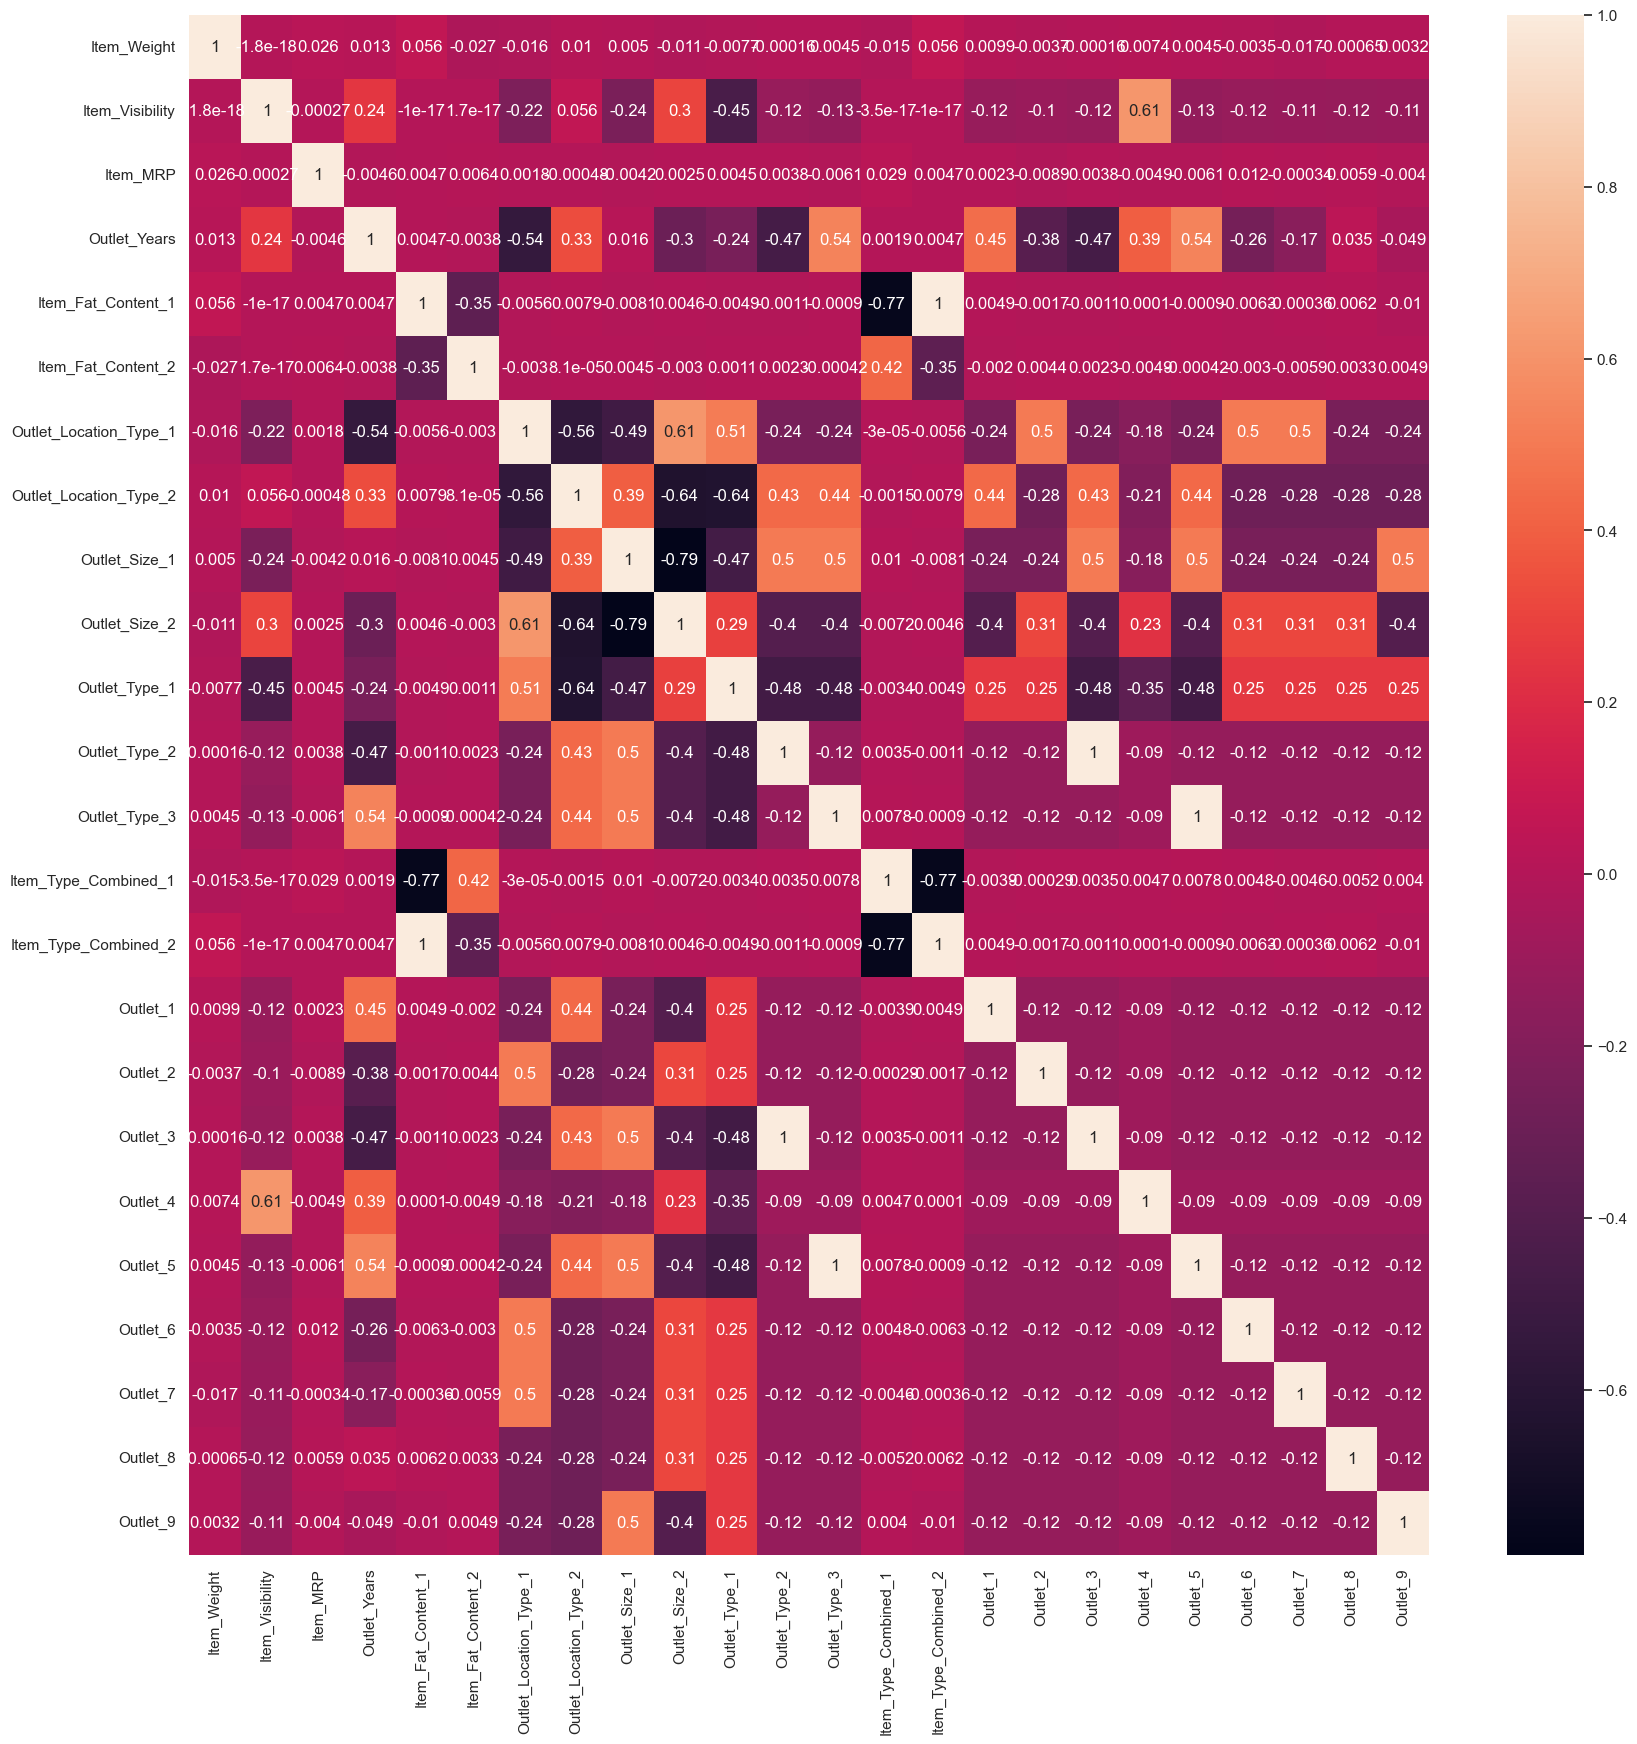

In [18]:
!pip install seaborn
import seaborn as sns #visualization package
sns.set(style = 'whitegrid')
plt.figure(figsize = (20,20))
sns.heatmap(X.corr(),annot = True)

# Hyperparameter Tuning

In [19]:
## Hyper Parameter Optimization

params={
 "learning_rate"    : [0.05, 0.10, 0.15, 0.20, 0.25, 0.30 ] ,
 "max_depth"        : [ 3, 4, 5, 6, 8, 10, 12, 15],
 "min_child_weight" : [ 1, 3, 5, 7 ],
 "gamma"            : [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
 "colsample_bytree" : [ 0.3, 0.4, 0.5 , 0.7 ]
    
}

In [20]:
## Hyperparameter optimization using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import xgboost

In [21]:
model = xgboost.XGBRegressor()

In [22]:
def timer(start_time=None):
    if not start_time:
        start_time = datetime.now()
        return start_time
    elif start_time:
        thour, temp_sec = divmod((datetime.now() - start_time).total_seconds(), 3600)
        tmin, tsec = divmod(temp_sec, 60)
        print('\n Time taken: %i hours %i minutes and %s seconds.' % (thour, tmin, round(tsec, 2)))

# Hyperparameter optimization using RandomizedSearchCV

In [23]:
from sklearn.metrics import mean_squared_error,make_scorer
random_search=RandomizedSearchCV(model,param_distributions=params,n_iter=5,scoring='neg_mean_squared_error',n_jobs=-1,cv=5,verbose=3)

In [24]:
from datetime import datetime
# Here we go
start_time = timer(None) # timing starts from this point for "start_time" variable
random_search.fit(X,y)
timer(start_time) # timing ends here for "start_time" variable

Fitting 5 folds for each of 5 candidates, totalling 25 fits

 Time taken: 0 hours 0 minutes and 8.33 seconds.


In [25]:
random_search

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.3, 0.4, ...], 'gamma': [0.0, 0.1, ...], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,5
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [26]:
means = random_search.cv_results_['mean_test_score']
params = random_search.cv_results_['params']
for mean, param in zip(means, params):
    print("%f with: %r" % (mean, param))
    if mean == min(means):
        print('Best parameters with the minimum Mean Square Error are:',param)

-1489431.391263 with: {'min_child_weight': 7, 'max_depth': 12, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 0.5}
Best parameters with the minimum Mean Square Error are: {'min_child_weight': 7, 'max_depth': 12, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 0.5}
-1273927.450845 with: {'min_child_weight': 7, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0.4, 'colsample_bytree': 0.4}
-1196329.550763 with: {'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0.0, 'colsample_bytree': 0.4}
-1225918.005894 with: {'min_child_weight': 7, 'max_depth': 4, 'learning_rate': 0.2, 'gamma': 0.0, 'colsample_bytree': 0.7}
-1184881.056006 with: {'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.7}


In [27]:
random_search

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.3, 0.4, ...], 'gamma': [0.0, 0.1, ...], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,5
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [28]:
random_search.best_params_

{'min_child_weight': 5,
 'max_depth': 5,
 'learning_rate': 0.05,
 'gamma': 0.2,
 'colsample_bytree': 0.7}

### Best parameters obtain from Hyperparameter optimization with the minimum Mean Square Error are:
{'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.4, 'colsample_bytree': 0.4} 

In [34]:
import xgboost

model = xgboost.XGBRegressor(
    base_score=0.5,
    booster='gbtree',
    colsample_bylevel=1,
    colsample_bynode=1,
    colsample_bytree=1,
    gamma=0.6,
    importance_type='gain',
    interaction_constraints='',
    learning_rate=0.4,
    max_delta_step=0,
    max_depth=15,
    min_child_weight=1,
    monotone_constraints='()',
    n_estimators=100,
    n_jobs=-1,
    num_parallel_tree=1,
    random_state=0,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    subsample=1,
    tree_method='hist',          # fast CPU training
    validate_parameters=1,
    verbosity=1,
    device='cpu'                 # ✅ replaces gpu_id
)


In [35]:
model.fit(X,y)

,objective,'reg:squarederror'
,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,1
,colsample_bynode,1
,colsample_bytree,1
,device,'cpu'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [24]:
#Predicting the Test set results
y_pred = model.predict(X)

### Evaluation using R2 Score and Mean Square Error 

In [25]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

score = r2_score(y,y_pred)
print("Score of Training:",100*score)
print("MAE : %.4g" % np.sqrt(mean_absolute_error(y,y_pred)))
print("RMSE : %.4g" % np.sqrt(mean_squared_error(y,y_pred)))

Score of Training: 99.99755323378365
MAE : 2.243
RMSE : 8.441


In [26]:
from sklearn.metrics import mean_squared_error,make_scorer
from sklearn.model_selection import cross_val_score

#Perform cross-validation:
cv_score = cross_val_score(model,X, y, cv=20, scoring='neg_mean_squared_error')
cv_score = np.sqrt(np.abs(cv_score))
    
#Print model report:
print("\nModel Report")
print("RMSE : %.4g" % np.sqrt(mean_squared_error(y,y_pred)))
print("CV Score : Mean - %.4g | Std - %.4g | Min - %.4g | Max - %.4g" % (np.mean(cv_score),np.std(cv_score),np.min(cv_score),np.max(cv_score)))


Model Report
RMSE : 8.441
CV Score : Mean - 1246 | Std - 59.53 | Min - 1145 | Max - 1351


______________________________________________________________________________________________________________________________
# Evaluating the model for Train and Test set  

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y ,test_size = 0.2,random_state = 2 )

In [28]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(6815, 24) (1704, 24) (6815,) (1704,)


In [29]:
#Predicting the Test set results
y_pred = model.predict(X_train)

In [30]:
from sklearn.metrics import r2_score,mean_squared_error

score = r2_score(y_train,y_pred)
print("Score of Training:",100*score)
print("RMSE : %.4g" % np.sqrt(mean_squared_error(y_train,y_pred)))

Score of Training: 99.99756585512752
RMSE : 8.428


In [31]:
from sklearn.metrics import mean_squared_error,make_scorer
from sklearn.model_selection import cross_val_score

#Perform cross-validation:
cv_score = cross_val_score(model,X_train, y_train, cv=20, scoring = make_scorer(mean_squared_error))
cv_score = np.sqrt(np.abs(cv_score))
    
#Print model report:
print("\nModel Report")
print("RMSE : %.4g" % np.sqrt(mean_squared_error(y_train,y_pred)))
print("CV Score : Mean - %.4g | Std - %.4g | Min - %.4g | Max - %.4g" % (np.mean(cv_score),np.std(cv_score),np.min(cv_score),np.max(cv_score)))


Model Report
RMSE : 8.428
CV Score : Mean - 1253 | Std - 59.76 | Min - 1152 | Max - 1386


In [32]:
y_test_pred = model.predict(X_test)

In [33]:
score = r2_score(y_test,y_test_pred)
print("Score of Testing:",100*score)
print("RMSE : %.4g" % np.sqrt(mean_squared_error(y_test,y_test_pred)))

Score of Testing: 99.99749835624469
RMSE : 8.491


In [34]:
#Perform cross-validation:
cv_score = cross_val_score(model,X_test, y_test, cv=20, scoring = make_scorer(mean_squared_error))
cv_score = np.sqrt(np.abs(cv_score))
    
#Print model report:
print("\nModel Report")
print("RMSE : %.4g" % np.sqrt(mean_squared_error(y_test,y_test_pred)))
print("CV Score : Mean - %.4g | Std - %.4g | Min - %.4g | Max - %.4g" % (np.mean(cv_score),np.std(cv_score),np.min(cv_score),np.max(cv_score)))


Model Report
RMSE : 8.491
CV Score : Mean - 1229 | Std - 121.7 | Min - 1041 | Max - 1465


In [35]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Calculate standard regression metrics
score = r2_score(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)

# Custom regression "accuracy"
# Accuracy = % of predictions within ±20% of actual value
tolerance = 0.2
accuracy = np.mean(np.abs((y_test - y_test_pred) / y_test) < tolerance) * 100

# Display results
print(f"R² Score: {score:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Accuracy: {accuracy:.2f}%")


R² Score: 1.0000
RMSE: 8.4914
MAE: 5.0687
Accuracy: 99.94%
